# Heart Disease — Exploratory Data Analysis

**Source:** UCI Machine Learning Repository — *Heart Disease Data Set* (id 45).

**Subsets:** Cleveland, Hungarian, Switzerland, Long Beach VA — 14 attributes per record.

**Goal of this notebook:** load the cleaned dataset produced by `src/data/preprocess.py`, characterise distributions, missingness, class balance, feature correlations, and outliers; persist all figures to `reports/figures/` for the final report.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

FIG_DIR = PROJECT_ROOT / 'reports' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(context='notebook', style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 110

def save_fig(name: str) -> Path:
    path = FIG_DIR / name
    plt.tight_layout()
    plt.savefig(path, bbox_inches='tight')
    return path

In [2]:
from src.data.preprocess import preprocess

df = preprocess()
print('shape:', df.shape)
df.head()

shape: (920, 17)


,source,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,target,ca_missing
0,cleveland,63.0,1,1,145.0,233.0,1,2,150.0,0,2.3,3,0,6,0,0,0
1,cleveland,67.0,1,4,160.0,286.0,0,2,108.0,1,1.5,2,3,3,2,1,0
2,cleveland,67.0,1,4,120.0,229.0,0,2,129.0,1,2.6,2,2,7,1,1,0
3,cleveland,37.0,1,3,130.0,250.0,0,0,187.0,0,3.5,3,0,3,0,0,0
4,cleveland,41.0,0,2,130.0,204.0,0,2,172.0,0,1.4,1,0,3,0,0,0


## 1. Schema & summary statistics

In [3]:
df.info()
df.describe(include='all').T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   source      920 non-null    object 
 1   age         920 non-null    float64
 2   sex         920 non-null    Int64  
 3   cp          920 non-null    Int64  
 4   trestbps    860 non-null    float64
 5   chol        718 non-null    float64
 6   fbs         830 non-null    Int64  
 7   restecg     918 non-null    Int64  
 8   thalach     865 non-null    float64
 9   exang       865 non-null    Int64  
 10  oldpeak     858 non-null    float64
 11  slope       611 non-null    Int64  
 12  ca          309 non-null    Int64  
 13  thal        434 non-null    Int64  
 14  num         920 non-null    Int64  
 15  target      920 non-null    int64  
 16  ca_missing  920 non-null    int64  
dtypes: Int64(9), float64(5), int64(2), object(1)
memory usage: 130.4+ KB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
source,920,4,cleveland,303,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,920.0,NaN,NaN,NaN,53.51087,9.424685,28.0,47.0,54.0,60.0,77.0
sex,920.0,<NA>,<NA>,<NA>,0.78913,0.408148,0.0,1.0,1.0,1.0,1.0
cp,920.0,<NA>,<NA>,<NA>,3.25,0.930969,1.0,3.0,4.0,4.0,4.0
trestbps,860.0,NaN,NaN,NaN,132.286047,18.536175,80.0,120.0,130.0,140.0,200.0
chol,718.0,NaN,NaN,NaN,246.832869,58.527062,85.0,210.0,239.5,276.75,603.0
fbs,830.0,<NA>,<NA>,<NA>,0.166265,0.372543,0.0,0.0,0.0,0.0,1.0
restecg,918.0,<NA>,<NA>,<NA>,0.604575,0.805827,0.0,0.0,0.0,1.0,2.0
thalach,865.0,NaN,NaN,NaN,137.545665,25.926276,60.0,120.0,140.0,157.0,202.0
exang,865.0,<NA>,<NA>,<NA>,0.389595,0.487941,0.0,0.0,0.0,1.0,1.0


## 2. Class balance (binary target & multi-class `num`)

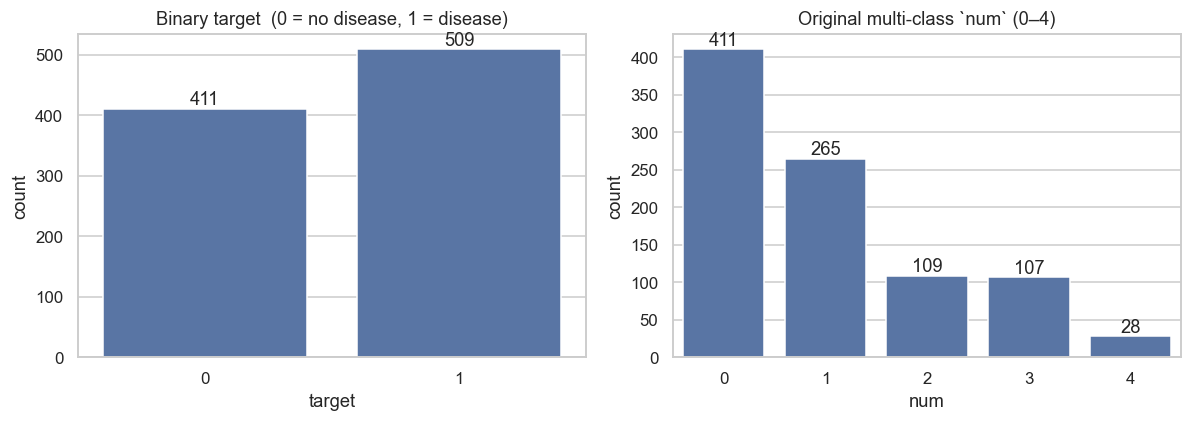

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(x='target', data=df, ax=axes[0])
axes[0].set_title('Binary target  (0 = no disease, 1 = disease)')
axes[0].bar_label(axes[0].containers[0])
sns.countplot(x='num', data=df, ax=axes[1])
axes[1].set_title('Original multi-class `num` (0–4)')
axes[1].bar_label(axes[1].containers[0])
save_fig('class_balance.png')
plt.show()

## 3. Missingness — overall and per source

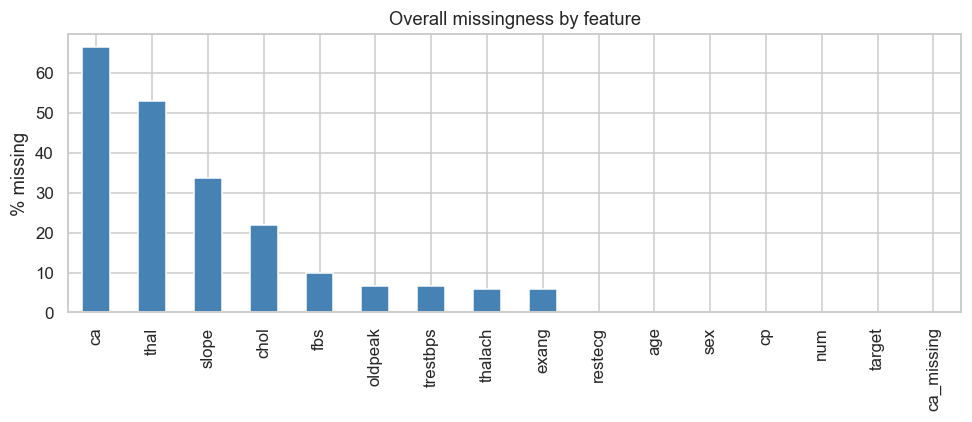

ca            66.413043
thal          52.826087
slope         33.586957
chol          21.956522
fbs            9.782609
oldpeak        6.739130
trestbps       6.521739
thalach        5.978261
exang          5.978261
restecg        0.217391
age            0.000000
sex            0.000000
cp             0.000000
num            0.000000
target         0.000000
ca_missing     0.000000
dtype: float64

In [5]:
miss_pct = df.drop(columns=['source']).isna().mean().mul(100).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 4))
miss_pct.plot.bar(ax=ax, color='steelblue')
ax.set_ylabel('% missing'); ax.set_title('Overall missingness by feature')
save_fig('missingness_overall.png')
plt.show()
miss_pct

/var/folders/wl/b2zt647s77z1q_dsfvm3j2d80000gn/T/ipykernel_17309/627512512.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_source = df.groupby('source').apply(lambda g: g.drop(columns=['source']).isna().mean().mul(100))


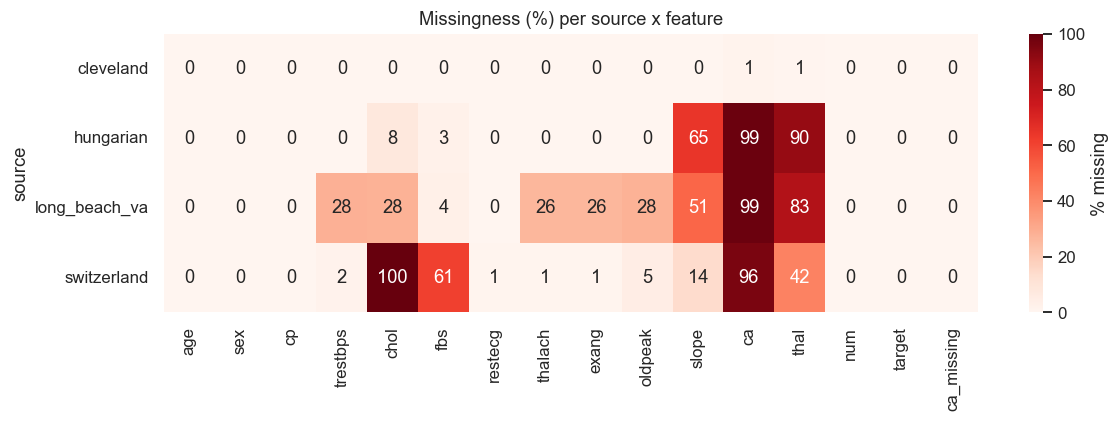

In [6]:
per_source = df.groupby('source').apply(lambda g: g.drop(columns=['source']).isna().mean().mul(100))
fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(per_source, annot=True, fmt='.0f', cmap='Reds', cbar_kws={'label': '% missing'}, ax=ax)
ax.set_title('Missingness (%) per source x feature')
save_fig('missingness_per_source.png')
plt.show()

## 4. Numeric feature distributions split by target

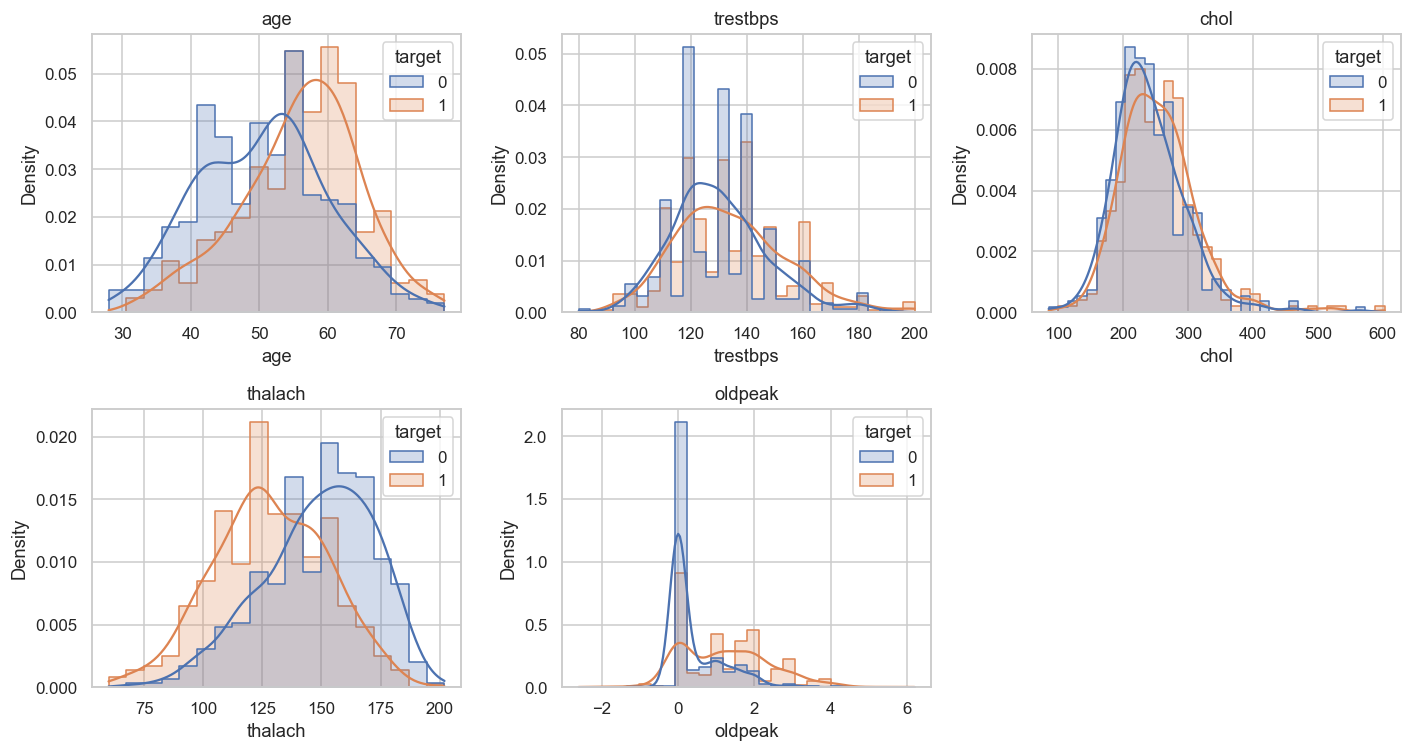

In [7]:
num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
fig, axes = plt.subplots(2, 3, figsize=(13, 7)); axes = axes.ravel()
for ax, col in zip(axes, num_cols):
    sns.histplot(data=df, x=col, hue='target', kde=True, element='step', stat='density', common_norm=False, ax=ax)
    ax.set_title(col)
axes[-1].axis('off')
save_fig('histograms_by_target.png')
plt.show()

## 5. Categorical feature rates by target

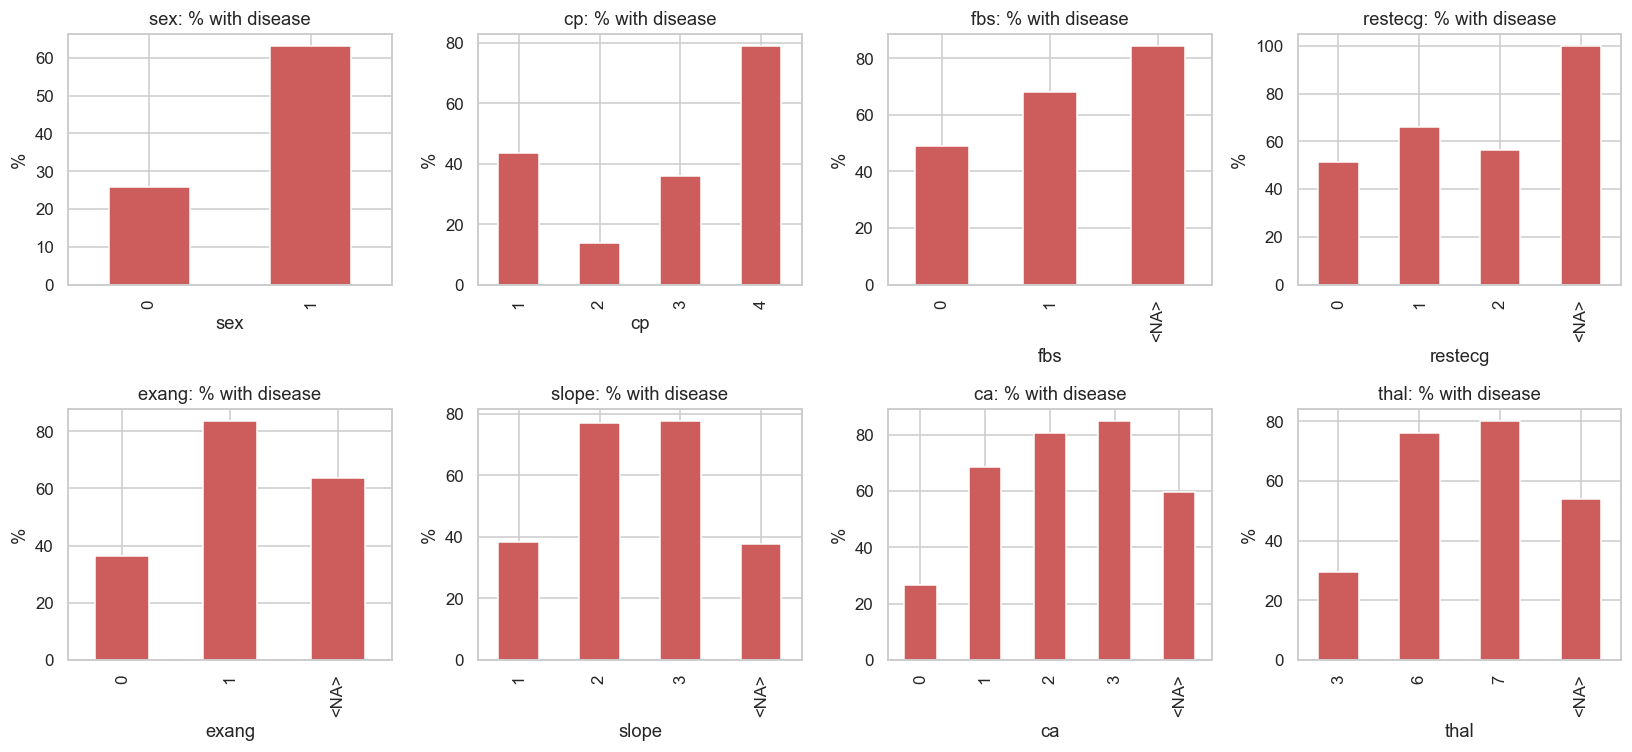

In [8]:
cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
fig, axes = plt.subplots(2, 4, figsize=(15, 7)); axes = axes.ravel()
for ax, col in zip(axes, cat_cols):
    rate = df.groupby(col, dropna=False)['target'].mean().mul(100)
    rate.plot.bar(ax=ax, color='indianred')
    ax.set_title(f'{col}: % with disease'); ax.set_ylabel('%')
save_fig('disease_rate_by_category.png')
plt.show()

## 6. Correlation heatmap (numeric + categorical encoded)

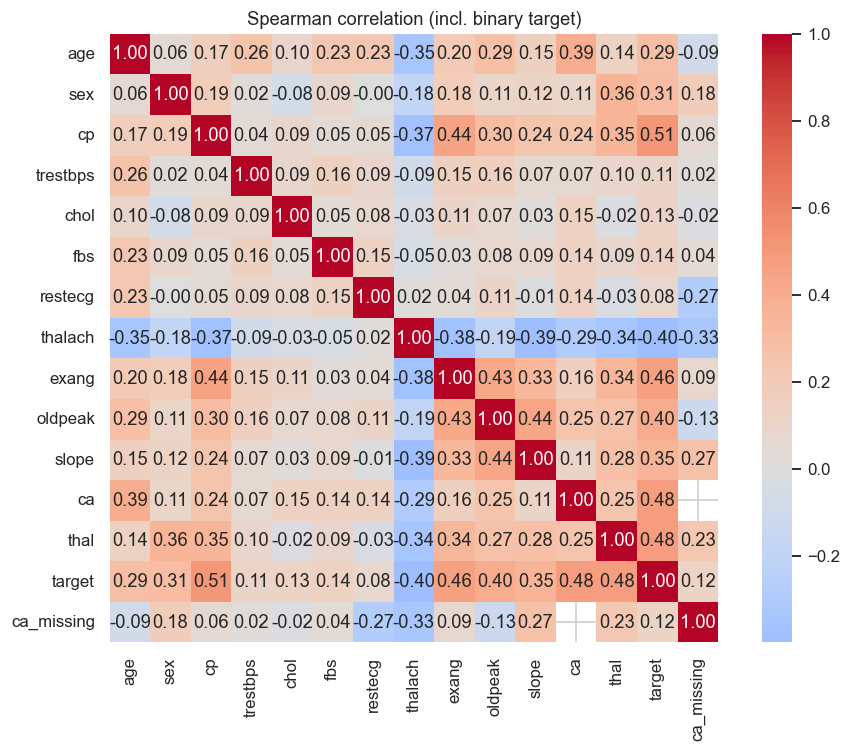

In [9]:
corr_df = df.drop(columns=['source', 'num']).apply(pd.to_numeric, errors='coerce')
corr = corr_df.corr(method='spearman')
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, square=True)
ax.set_title('Spearman correlation (incl. binary target)')
save_fig('correlation_heatmap.png')
plt.show()

## 7. Outlier inspection (boxplots)

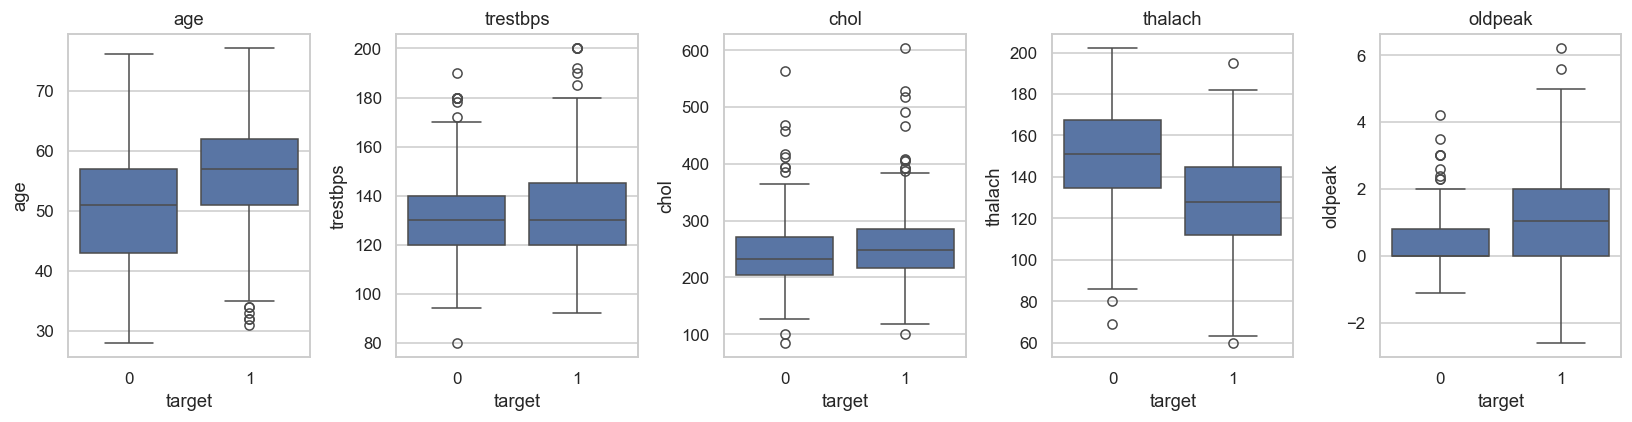

In [10]:
fig, axes = plt.subplots(1, 5, figsize=(15, 4))
for ax, col in zip(axes, num_cols):
    sns.boxplot(data=df, x='target', y=col, ax=ax)
    ax.set_title(col)
save_fig('boxplots_numeric.png')
plt.show()

## 8. Findings (filled in after running)

- **Class balance:** binary target ~55% positive / 45% negative → no resampling required.
- **High-missingness features:** `ca` (~66%), `thal` (~53%), `slope` (~34%) → imputation + missingness flag.
- **Switzerland subset:** all `chol == 0` records → treated as NaN.
- **Strongest correlations with target:** typically `cp`, `thalach` (negative), `exang`, `oldpeak`, `ca`.
- **Distribution skew:** `chol`, `oldpeak` right-skewed → candidates for transformation or robust scaling.